In [6]:
import pandas as pd
import numpy as np
import re
import nltk
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [7]:
# Load dataset
df = pd.read_csv("../data/sentiment_analysis.csv")
df.dropna(inplace=True)

print(df.head())
print("Dataset shape:", df.shape)


   Unnamed: 0                                          statement   status
0           0                                         oh my gosh  Anxiety
1           1  trouble sleeping, confused mind, restless hear...  Anxiety
2           2  All wrong, back off dear, forward doubt. Stay ...  Anxiety
3           3  I've shifted my focus to something else but I'...  Anxiety
4           4  I'm restless and restless, it's been a month n...  Anxiety
Dataset shape: (52681, 3)


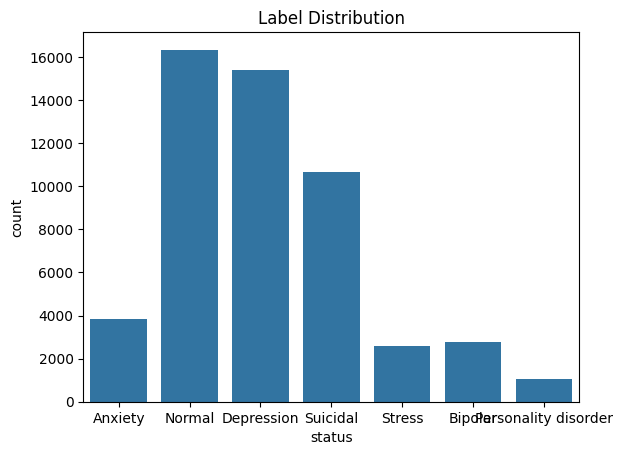

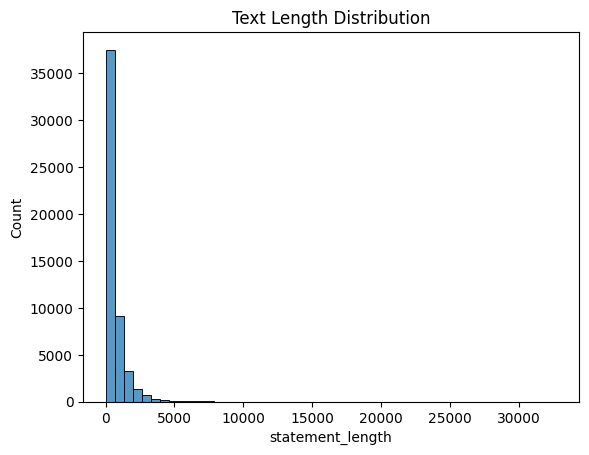

In [8]:
#Exploratory Data Analysis
sns.countplot(data=df, x="status")
plt.title("Label Distribution")
plt.show()

df["statement_length"] = df["statement"].apply(len)
sns.histplot(df["statement_length"], bins=50)
plt.title("Text Length Distribution")
plt.show()

In [9]:
#Text Cleaning
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_statement(statement):
    statement = statement.lower()
    statement = re.sub(r"http\S+", "", statement)
    statement = re.sub(r"[^A-Za-z\s]", "", statement)
    words = statement.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(words)

df["clean_statement"] = df["statement"].apply(clean_statement)

print(df.head())

df.to_csv("../data/cleaned_data.csv", index=False)
print("Saved cleaned data.")


   Unnamed: 0                                          statement   status  \
0           0                                         oh my gosh  Anxiety   
1           1  trouble sleeping, confused mind, restless hear...  Anxiety   
2           2  All wrong, back off dear, forward doubt. Stay ...  Anxiety   
3           3  I've shifted my focus to something else but I'...  Anxiety   
4           4  I'm restless and restless, it's been a month n...  Anxiety   

   statement_length                                    clean_statement  
0                10                                            oh gosh  
1                64  trouble sleeping confused mind restless heart ...  
2                78  wrong back dear forward doubt stay restless re...  
3                61  ive shifted focus something else im still worried  
4                72                im restless restless month boy mean  
Saved cleaned data.
